In [1]:
# 第一步：导包
%matplotlib inline

# 导入分类决策树
from sklearn.tree import DecisionTreeClassifier 

# 随机森林在ensemble模块下，这里是随机森林分类器，当然肯定还有随机森林回归器，因为决策树也会有回归决策树
from sklearn.ensemble import RandomForestClassifier

# 红酒数据集
from sklearn.datasets import load_wine

# 数据集的划分
from sklearn.model_selection import train_test_split

# K折交叉验证对象
from sklearn.model_selection import cross_val_score #交叉验证
import matplotlib.pyplot as plt

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
# 第二步：加载数据集
wine = load_wine()

# 简单探索数据集
wine.data
# 简单探索标签
wine.target

array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]], shape=(178, 13))

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

In [3]:
# 第三步：使用基本的sklearn的决策树分类器对象构建一个简单的分类决策树模型

# 1.先划分数据集为训练集和测试集
Xtrain,Xtest,Ytrain,Ytest = train_test_split(wine.data,wine.target,test_size = 0.3)

# 2.实例化决策树分类器对象，给定一个固定的随机种子0
clf = DecisionTreeClassifier(random_state = 0)

# 3.实例化随机森林分类器对象，给定相同的固定的随机种子0
rfc = RandomForestClassifier(random_state = 0)

# 4.完成单个分类决策树和分类随机森林的模型训练
clf = clf.fit(Xtrain,Ytrain)
rfc = rfc.fit(Xtrain,Ytrain)

# 5.计算两个模型的评估分数
score_c = clf.score(Xtest,Ytest)
score_r = rfc.score(Xtest,Ytest)

# 测试
print('Single Tree:{};Random Forest:{}'.format(score_c,score_r))

Single Tree:0.8703703703703703;Random Forest:0.9814814814814815


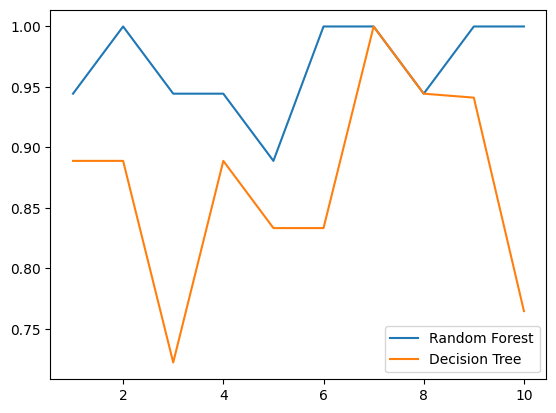

In [4]:
# 第四步：绘制随机森林和单个决策树在一组相同K折交叉验证下的效果对比

# 1.创建带有必备参数n_estimators的新的随机森林分类器对象 - n_estimators表示森林中基决策树的数量
rfc = RandomForestClassifier(n_estimators = 25)

# 2.将随机森林分类器对象交由K折交叉验证对象完成10折交叉验证过程
rfc_s = cross_val_score(rfc,wine.data,wine.target,cv = 10)

# 3.创建决策树分类器对象
clf = DecisionTreeClassifier(random_state = 0)

# 4.将该决策树分类器对象交由K折交叉验证对象完成10折交叉验证过程
clf_s = cross_val_score(clf,wine.data,wine.target,cv = 10)

# 5.可视化：横坐标为折数，纵坐标为K折交叉验证后的得分
plt.plot(range(1,11),rfc_s,label = 'Random Forest')
plt.plot(range(1,11),clf_s,label = 'Decision Tree')

plt.legend()
plt.show()

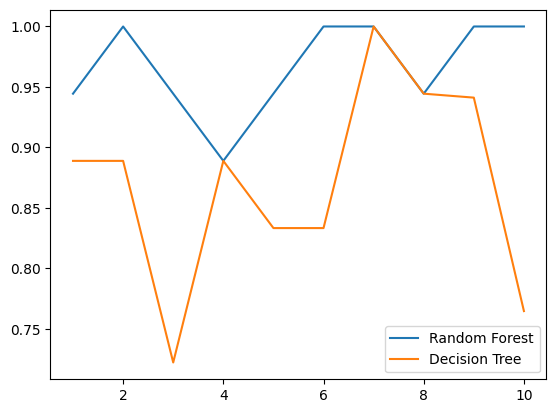

In [5]:
# 上述画图过程的for循环实现
label = 'Random Forest'
for model in [RandomForestClassifier(n_estimators = 25),DecisionTreeClassifier(random_state = 0)]:
    score = cross_val_score(model,wine.data,wine.target,cv = 10)
    plt.plot(range(1,11),score,label = label)
    plt.legend()
    label = 'Decision Tree'

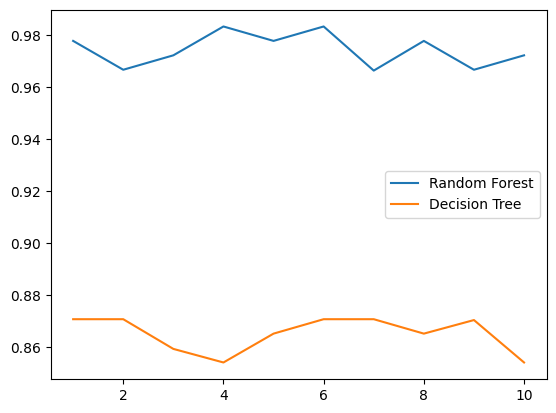

In [6]:
# 第五步：在一组10折交叉验证下，无法清楚的看出随机森林与单个分类决策树的模型评估的差异化，现在做10组10折交叉验证，再次可视化对应的评估结果
# 即可清楚的看出随机森林与单个分类决策树的模型评估差异化

# 等待保存每一组10折交叉验证后计算的随机森林和单个分类决策树的评估结果
rfc_1 = []
clf_1 = []

for i in range(10):
    
    # 1.创建带有必备参数n_estimators的新的随机森林分类器对象 - n_estimators表示森林中基决策树的数量
    rfc = RandomForestClassifier(n_estimators = 25)

    # 2.将随机森林分类器对象交由K折交叉验证对象完成10折交叉验证过程，并获得分数后直接将分数值添加到对应的序列
    rfc_1.append(cross_val_score(rfc,wine.data,wine.target,cv = 10).mean())

    # 3.创建决策树分类器对象
    clf = DecisionTreeClassifier()

    # 4.将该决策树分类器对象交由K折交叉验证对象完成10折交叉验证过程,并获得分数后直接将分数值添加到对应的序列
    clf_1.append(cross_val_score(clf,wine.data,wine.target,cv = 10).mean())


# 5.可视化
label = 'Random Forest'
for score in [rfc_1,clf_1]:
    
    plt.plot(range(1,11),score,label = label)
    
    label = 'Decision Tree'

plt.legend()

经过200次验证，随机森林中基决策树的个数为19时，对应随机森林模型评估分数值达       到了最大，最大值为：0.9888888888888889


<Figure size 2000x500 with 0 Axes>

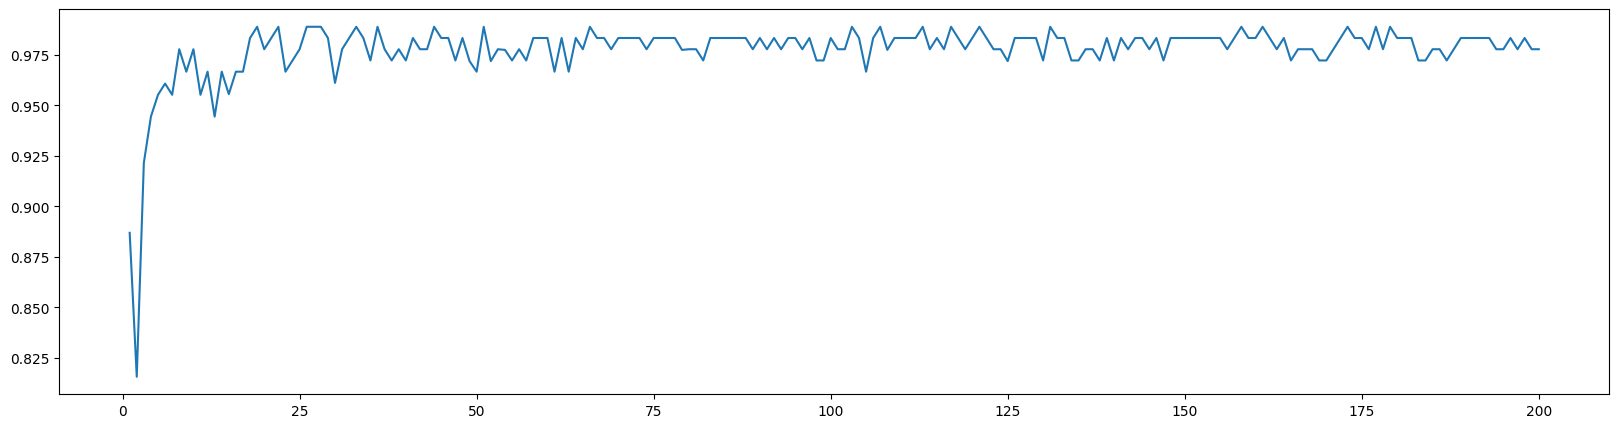

In [7]:
# 第六步：绘制超参数n_estimators的学习曲线，观察其10折交叉验证得分情况在超参数n_estimators给定不同值时所得的评分结果的变化趋势
# 并且要从中找出当10折交叉验证结果达到最大值时，对应的n_estimators应该要取的值为多少 - 表示在当前红酒数据集下，如果需要构建分类随机森林
# 最佳的基决策树的数量为多少

# 准备一个保存分数结果的对象
superpa = []
x = 0
for i in range(200):
    x += 1
    # 1.创建带有必备参数n_estimators的新的随机森林分类器对象 - n_estimators表示森林中基决策树的数量
    rfc = RandomForestClassifier(n_estimators = i + 1)
    
    # 2.将随机森林分类器对象交由K折交叉验证对象完成10折交叉验证过程，并获得分数后直接将分数值添加到对应的序列
    superpa.append(cross_val_score(rfc,wine.data,wine.target,cv = 10).mean())

print('经过{}次验证，随机森林中基决策树的个数为{}时，对应随机森林模型评估分数值达 \
      到了最大，最大值为：{}'.format(x,superpa.index(max(superpa)) + 1,max(superpa)))

# 创建画布
plt.figure(figsize=[20,5])

# 绘图
plt.plot(range(1,201),superpa)
plt.show()

In [8]:
import numpy as np
from scipy.special import comb# comb为组合，scipy用来配合计算numpy等
np.array([comb(25,i)*(0.2**i)*((1-0.2)**(25-i)) for i in range(13,26)]).sum()

np.float64(0.00036904803455582827)

In [9]:
rfc = RandomForestClassifier(n_estimators=20,random_state=2)
rfc = rfc.fit(Xtrain, Ytrain)

rfc.estimators_[0].random_state#打出森林中第一颗树的random_state
for i in range(len(rfc.estimators_)):#循环打出森林中所有的树的random_state
    print(rfc.estimators_[i].random_state)

1872583848

1872583848
794921487
111352301
1853453896
213298710
1922988331
1869695442
2081981515
1805465960
1376693511
1418777250
663257521
878959199
854108747
512264917
515183663
1287007039
2083814687
1146014426
570104212


In [10]:
rfc = RandomForestClassifier(n_estimators=25,oob_score=True)
rfc = rfc.fit(wine.data,wine.target)#不需要划分测试集和训练集，oob_score=True会使用包外数据来当测试集

In [11]:

rfc.oob_score_

0.9719101123595506

Text(0.5, 0, "individual estimator's error")

Text(0, 0.5, "RandomForest's error")

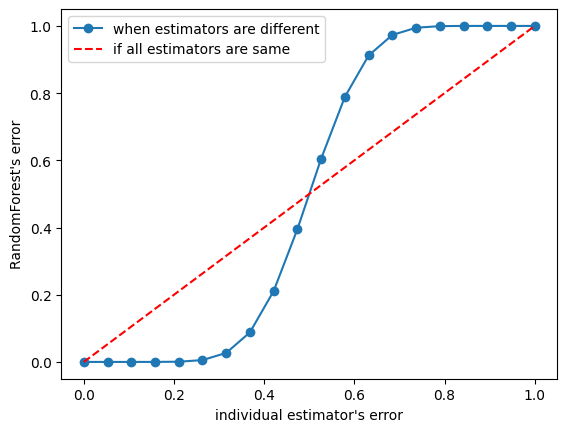

In [12]:
import numpy as np
x = np.linspace(0,1,20) 
y = []
for epsilon in np.linspace(0,1,20):
    E = np.array([comb(25,i)*(epsilon**i)*((1-epsilon)**(25-i)) for i in range(13,26)]).sum()
    y.append(E)
plt.plot(x,y,"o-",label="when estimators are different")
plt.plot(x,x,"--",color="red",label="if all estimators are same")
plt.xlabel("individual estimator's error")
plt.ylabel("RandomForest's error")
plt.legend()
plt.show()

In [16]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
diabetes = load_diabetes()
regressor = RandomForestRegressor(n_estimators=100,random_state=0,oob_score = True)
cross_val_score(regressor, diabetes.data, diabetes.target, cv=10,scoring = "neg_mean_squared_error")


array([-3566.19025778, -2846.88913556, -3231.57026136, -3290.84103636,
       -3346.63108409, -3809.64030227, -3495.86670227, -2822.85539091,
       -4884.50012273, -2672.38819545])

In [23]:
import numpy as np
import pandas as pd

# 导入鸢尾花数据集
from sklearn.datasets import load_iris

# 导入Adaboost对象
from sklearn.ensemble import AdaBoostClassifier

# 导入CART分类树对象
from sklearn.tree import DecisionTreeClassifier

# 导入数据集划分对象
from sklearn.model_selection import train_test_split

# 导入预测准确率计算对象accuracy_score
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
%matplotlib inline

In [24]:
# 加载数据集,并完成数据集划分
iris = load_iris()

# 数据集划分
Xtrain,Xtest,Ytrain,Ytest = train_test_split(iris.data,iris.target,test_size = 0.3)

In [25]:
# 定义一个弱分类器对象 - 这里我们采用的就是CART分类树模型，建立该模型并完成训练，同时评估其分类预测的准确率

# 实例化CART分类树模型对象并完成模型训练
weakClassifier = DecisionTreeClassifier(max_depth = 5).fit(Xtrain,Ytrain)

# 获取预测结果
dtc_y_pred = weakClassifier.predict(Xtest)
print('CART分类树预测的准确率：{}'.format(accuracy_score(Ytest,dtc_y_pred)))

CART分类树预测的准确率：0.9777777777777777


In [ ]:
# 构建Adaboost自适应增强分类器模型，并完成训练，且获取预测结果
# 注意：sklearn 1.4+ 中 base_estimator 改为 estimator，algorithm 参数已移除
# （DecisionTreeClassifier 支持 predict_proba，自动使用 SAMME.R 算法）
clf = AdaBoostClassifier(
    estimator = DecisionTreeClassifier(max_depth=5),
    n_estimators = 300,
    learning_rate = 0.4
).fit(Xtrain,Ytrain)

# 获取预测结果
clf_y_pred = clf.predict(Xtest)
print('Adaboost自适应增强分类模型预测的准确率：{}'.format(accuracy_score(Ytest,clf_y_pred)))
clf.feature_importances_
clf.estimator_weights_